### StudentRegressorExamScore

In [3]:
import pandas as pd

df = pd.read_csv("data/Student_Performance.csv")


In [4]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [5]:
df.dropna(inplace=True)

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'school_type', 'parent_education',
       'study_hours', 'attendance_percentage', 'internet_access',
       'travel_time', 'extra_activities', 'study_method', 'math_score',
       'science_score', 'english_score', 'overall_score', 'final_grade'],
      dtype='object')

In [7]:
df.isna().sum()

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  fi

## 1. Environment Setup
##### Importing the necessary libraries and initial configuration.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
import joblib

In [10]:
# 2. Drop leakage + useless columns
# =========================
df = df.drop(columns=[
    "student_id",
    "math_score",
    "science_score",
    "english_score",
    "final_grade",
    "parent_education",
])

In [19]:
# df = df.drop(columns=["quiz_attempts", "quiz_avg_score"])

In [11]:
df.columns

Index(['age', 'gender', 'school_type', 'study_hours', 'attendance_percentage',
       'internet_access', 'travel_time', 'extra_activities', 'study_method',
       'overall_score'],
      dtype='object')

In [12]:
# Target

y = df["overall_score"]

# Features
X = df.drop(columns=["overall_score"])

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.941693443028177
MAE: 3.376940800000001


In [14]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp)

                       feature  importance
1                  study_hours    0.830599
2        attendance_percentage    0.118147
0                          age    0.011255
5           school_type_public    0.003765
10        extra_activities_yes    0.003762
4                 gender_other    0.003354
3                  gender_male    0.003229
7        travel_time_30-60 min    0.003170
9          travel_time_>60 min    0.002967
12          study_method_mixed    0.002899
8          travel_time_<15 min    0.002895
14  study_method_online videos    0.002840
6          internet_access_yes    0.002829
13          study_method_notes    0.002790
11    study_method_group study    0.002752
15       study_method_textbook    0.002747


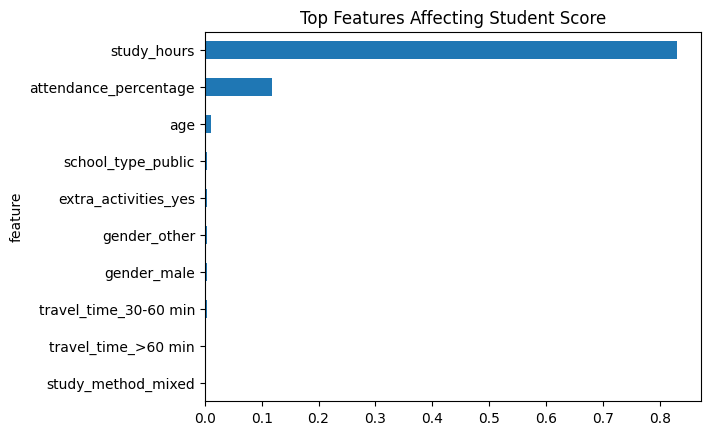

In [15]:
feat_imp.head(10).plot(
    kind='barh',
    x='feature',
    y='importance',
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Top Features Affecting Student Score")
plt.show()

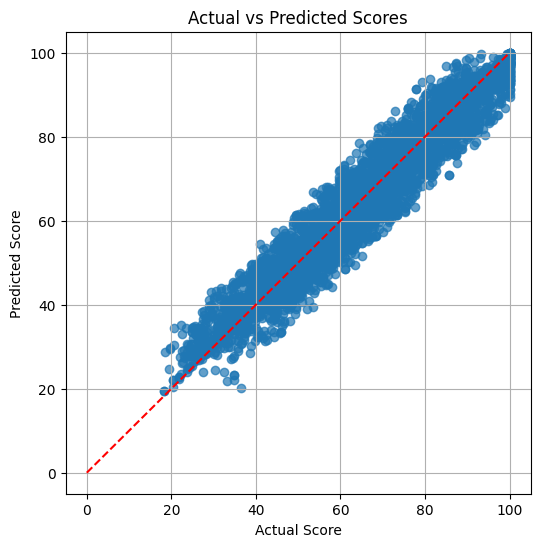

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot([0,100],[0,100],'r--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")

plt.grid(True)

plt.show()

In [17]:
importance = model.feature_importances_

In [19]:
features = X.columns

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

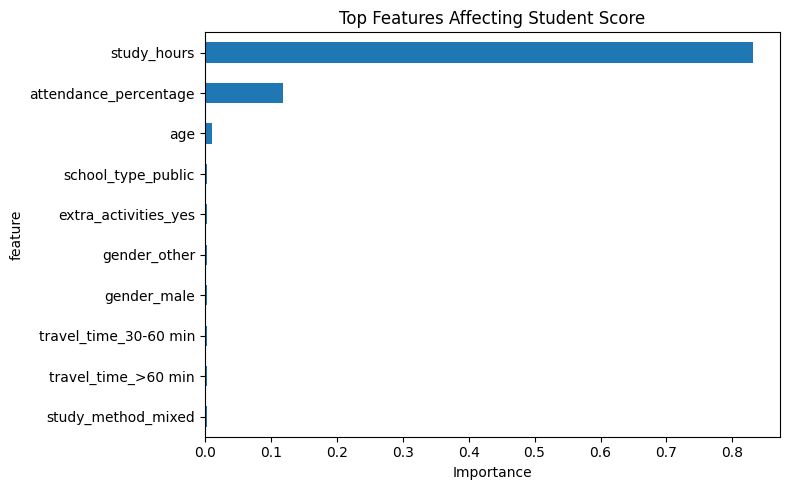

In [20]:
feat_imp.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.title("Top Features Affecting Student Score")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### RandomForestClassifier

In [21]:
def label_score(x):
    if x < 60:
        return 0
    elif x < 80:
        return 1
    else:
        return 2

df["performance_label"] = df["overall_score"].apply(label_score)

In [22]:
from sklearn.model_selection import train_test_split

X_cls = df.drop(["overall_score", "performance_label"], axis=1)
y_cls = df["performance_label"]

# Encoding categorical features
X_cls = pd.get_dummies(X_cls, drop_first=True)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestClassifier

model_cls = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)
model_cls.fit(X_train_cls, y_train_cls)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 1) Performance Level Distribution

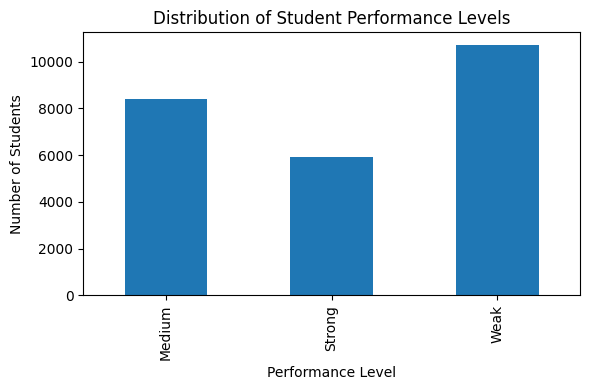

In [26]:
import matplotlib.pyplot as plt

labels = y_cls.map({0: "Weak", 1: "Medium", 2: "Strong"})

plt.figure(figsize=(6,4))
labels.value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Student Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, classification_report

preds_cls = model_cls.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, preds_cls))
print(classification_report(y_test_cls, preds_cls))

Accuracy: 0.9108
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2168
           1       0.86      0.87      0.86      1634
           2       0.91      0.91      0.91      1198

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



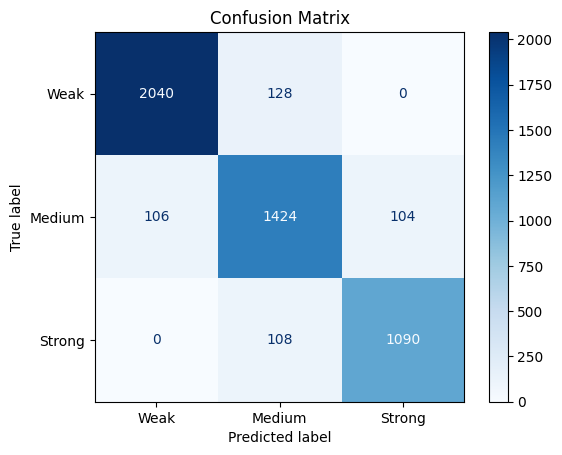

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_cls, preds_cls)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Weak", "Medium", "Strong"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [25]:
importance_df = pd.DataFrame({
    "feature": X_cls.columns,
    "importance": model_cls.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

                  feature  importance
1             study_hours    0.659355
2   attendance_percentage    0.174317
0                     age    0.042474
5      school_type_public    0.014488
10   extra_activities_yes    0.014350
4            gender_other    0.011201
3             gender_male    0.010562
7   travel_time_30-60 min    0.010091
8     travel_time_<15 min    0.009608
9     travel_time_>60 min    0.008655


#### 2) Feature Importance

<Figure size 800x500 with 0 Axes>

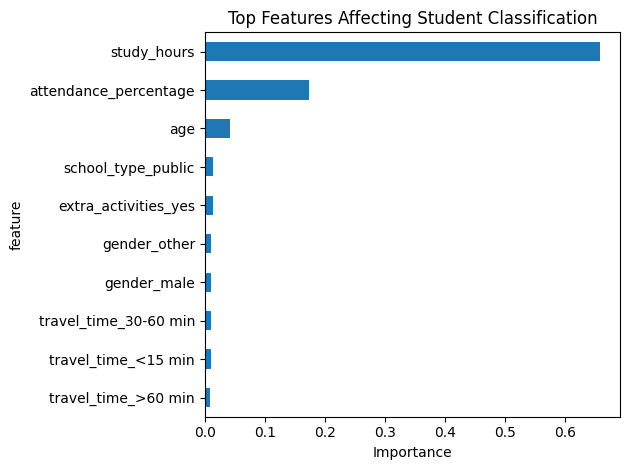

In [ ]:
plt.figure(figsize=(8,5))

importance_df.head(10).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False
)

plt.title("Top Features Affecting Student Classification")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

In [30]:
joblib.dump(model, "rf_regressor.pkl")
joblib.dump(model_cls, "rf_classifier.pkl")

['rf_classifier.pkl']